In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
import requests
import io

In [2]:
def load_worldbank_data(countries=['CZE', 'HUN']):
    all_data = []

    for country in countries:
        url = f"https://api.worldbank.org/v2/country/{country}/indicator/SP.POP.TOTL"
        params = {'format': 'json', 'date': '1960:2023', 'per_page': 1000}

        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            for entry in data[1]:
                if entry['value'] is not None:
                    all_data.append({
                        'country': entry['country']['value'],
                        'country_code': entry['country']['id'],
                        'year': int(entry['date']),
                        'population': float(entry['value'])
                    })

    return pd.DataFrame(all_data)

In [3]:
df = load_worldbank_data(['CZE', 'HUN'])

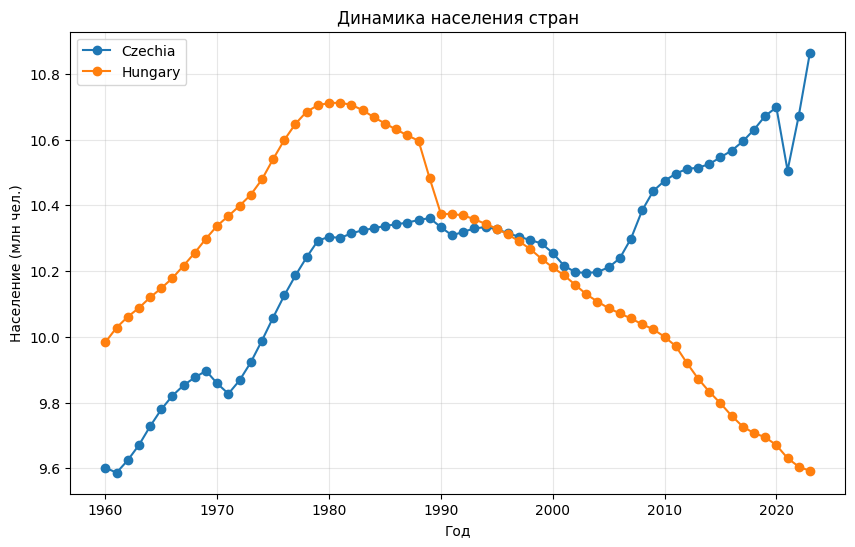

In [4]:

plt.figure(figsize=(10, 6))
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    plt.plot(country_data['year'], country_data['population']/1e6,
             marker='o', label=country)

plt.xlabel('Год')
plt.ylabel('Население (млн чел.)')
plt.title('Динамика населения стран')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
df = load_worldbank_data(["JPN"])

In [26]:
country_data = df[df['country'] == 'Japan']
years = country_data['year'].values
population = country_data['population'].values / 1_000_000
t = years - years[0]

In [29]:
def malthus(t, P0, r):
    return P0 * np.exp(r * t)

def verhulst(t, P0, r, K):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

def arnold(t, P0, r, K, C):
    dt = 1
    P = np.zeros(len(t))
    P[0] = P0
    for i in range(1, len(t)):
        P[i] = P[i-1] + r * P[i-1] * (1 - P[i-1] / K) - C * P[i-1]
    return P

In [31]:
years = df['year'].values
population = df['population'].values
t = np.arange(len(years))

In [ ]:
split = int(len(years) * 0.8)

In [38]:
t_train = t[:split]
pop_train = population[:split]

t_test = t[split:]
pop_test = population[split:]
years_test = years[split:]

In [39]:
print(f" Training on years: {years[0]}-{years[split-1]}")
print(f" Testing on years: {years[split]}-{years[-1]}")

 Training on years: 1960-2010
 Testing on years: 2011-2023


In [40]:
popt_m, _ = curve_fit(malthus, t_train, pop_train, p0=[pop_train[0], 0.01])
P0_m, r_m = popt_m

popt_v, _ = curve_fit(verhulst, t_train, pop_train, p0=[pop_train[0], 0.02, pop_train.max()*1.2])
P0_v, r_v, K_v = popt_v

popt_a, _ = curve_fit(arnold, t_train[::2], pop_train[::2],
                    p0=[pop_train[0], 0.02, pop_train.max()*1.2, 0.001])
P0_a, r_a, K_a, C_a = popt_a


pred_m = malthus(t_test, P0_m, r_m)  # Мальтус
pred_v = verhulst(t_test, P0_v, r_v, K_v)  # Ферхюльст
pred_a = arnold(t_test, P0_a, r_a, K_a, C_a)  # Арнольд

In [41]:
error_m = rmse(pop_test, pred_m)
error_v = rmse(pop_test, pred_v)
error_a = rmse(pop_test, pred_a)
print(f"  Malthus: error = {error_m:,.0f}")
print(f"  Verhulst: error = {error_v:,.0f}")
print(f"  Arnold: error = {error_a:,.0f}")

  Malthus: error = 15,077,122
  Verhulst: error = 3,708,108
  Arnold: error = 22,071,684


In [42]:
if error_a < error_v and error_a < error_m:
    best_model = "Arnold"
elif error_v < error_m:
    best_model = "Verhulst"
else:
    best_model = "Malthus"

print(f"\n BEST MODEL: {best_model}")


 BEST MODEL: Verhulst


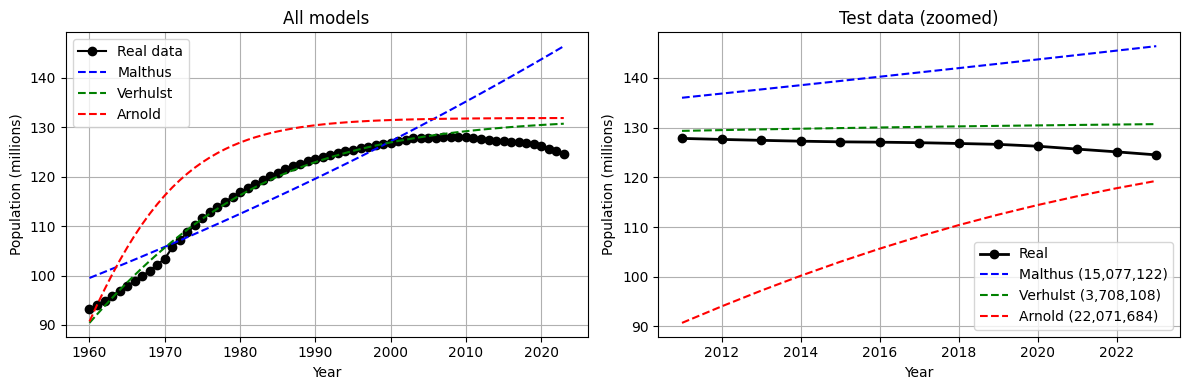

In [48]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(years, population / 1_000_000, 'ko-', label='Real data')


plt.plot(years, malthus(t, P0_m, r_m) / 1_000_000, 'b--', label='Malthus')
plt.plot(years, verhulst(t, P0_v, r_v, K_v) / 1_000_000, 'g--', label='Verhulst')
plt.plot(years, arnold(t, P0_a, r_a, K_a, C_a) / 1_000_000, 'r--', label='Arnold')

plt.xlabel('Year')
plt.ylabel('Population (millions)')
plt.title('All models')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(years_test, pop_test / 1_000_000, 'ko-', label='Real', linewidth=2)
plt.plot(years_test, pred_m / 1_000_000, 'b--', label=f'Malthus ({error_m:,.0f})')
plt.plot(years_test, pred_v / 1_000_000, 'g--', label=f'Verhulst ({error_v:,.0f})')
plt.plot(years_test, pred_a / 1_000_000, 'r--', label=f'Arnold ({error_a:,.0f})')

plt.xlabel('Year')
plt.ylabel('Population (millions)')
plt.title('Test data (zoomed)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


